In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json


In [11]:
def radius_95(Count):
    if 0<np.log10(Count)<=2.1393:
        return 10**(-0.4958*np.log10(Count)+0.1932)
    elif 2.1393<np.log10(Count)<=3.3:
        return 10**(-0.2064*np.log10(Count)-0.4260)

In [12]:
distance_parsecs = 5400

#loading the data from sources.txt and creating a dataframe with the corresponding columns
with open("C:/Users/HP/Desktop/Curso de Python/Workspace/miweb/Astronomía/sources.txt", "r") as f:
    NGC6809_sources = json.load(f)
df = pd.DataFrame(NGC6809_sources)

#Boresigth (BS - CX1)
BSRA = 295.0357771-295.0358042
BSDecl = -30.9811814+30.9811333

#RA to degrees, Decl to degrees, and extract counts from Xsoft, Xmed, Xhard
ra_parts = df["RA"].str.extract(r"(\d+)h(\d+)m([\d\.]+)s")
df["RA"] = 15*(ra_parts[0].astype(float)+ra_parts[1].astype(float)/60+ra_parts[2].astype(float)/3600) + BSRA
decl_parts = df["Decl"].str.extract(r"([+-]?\d+)d(\d+)m([\d\.]+)s")
df["Decl"] = decl_parts[0].astype(float)-decl_parts[1].astype(float)/60-decl_parts[2].astype(float)/3600 + BSDecl

#Extracting counts and creating total_count column
xsoft = df["Xsoft"].str.extract(r"(\d+)/([\d\.]+)").astype(float)
xmed = df["Xmed"].str.extract(r"(\d+)/([\d\.]+)").astype(float)
xhard = df["Xhard"].str.extract(r"(\d+)/([\d\.]+)").astype(float)
df["total_count"] = xsoft[0]+xmed[0]+xhard[0]

#Creating the columns for the radii and filling them with the corresponding values
df['r95'] = np.nan
for i in df.index:
    df.loc[i, "r95"] = radius_95(df["total_count"][i])/3600
    
#distance from NGC6809, aprox 5400 parsecs (1.666e+22 cm)
# parsecs * parsecs to light years * speed of light in cm/s * seconds in a year
d = distance_parsecs * 3.26156 *30000000000*365*24*60*60

#Using the formula of luminosity and flux: Lx = 4*pi*d^2*fx and creating the columns for luminosity and hardness 
df["Lx_0.5-2.5"] = df["Fx_0.5-2.5"] * 4 * np.pi * d*d
df["Lx_2.5-6.0"] = df["Fx_2.5-6.0"] * 4 * np.pi * d*d

#Dropping the columns that are not needed and saving the dataframe as a csv file
df.drop(columns = ["Xsoft", "Xmed", "Xhard", "Fx_0.5-2.5", "Fx_2.5-6.0", "total_count"], inplace = True)

df.index.name = "id"

In [13]:
df["Lx_0.5-6.0"] = df["Lx_0.5-2.5"] + df["Lx_2.5-6.0"]
df["Lx_0.5-2.5 / Lx_2.5-6.0"] = df["Lx_0.5-2.5"]/df["Lx_2.5-6.0"]
df["log(Lx_0.5-6.0)"] = np.log10(df["Lx_0.5-6.0"])
df["log(Lx_0.5-2.5 / Lx_2.5-6.0)"] = np.log10(df["Lx_0.5-2.5 / Lx_2.5-6.0"])


In [14]:
conditions = [(df["log(Lx_0.5-6.0)"] >= 31.6020599913) & (-3.996566*df["log(Lx_0.5-2.5 / Lx_2.5-6.0)"] + 33.6003433 - df["log(Lx_0.5-6.0)"] < 0),
              (df["log(Lx_0.5-6.0)"] >= 31.6020599913) & (-3.996566*df["log(Lx_0.5-2.5 / Lx_2.5-6.0)"] + 33.6003433 - df["log(Lx_0.5-6.0)"] >= 0),
              (df["log(Lx_0.5-6.0)"] < 31.6020599913) & (df["log(Lx_0.5-6.0)"] >= 30.6020599913),
              df["log(Lx_0.5-6.0)"] < 30.6020599913]
choices = ["LMXRB",'CV','CV & AB','AB']

In [15]:
df ["Hardness_classification"] = np.select(conditions, choices, default="")
df.drop(columns = ["Lx_0.5-6.0", "Lx_0.5-2.5 / Lx_2.5-6.0", "Lx_0.5-2.5", "Lx_2.5-6.0"], inplace = True)
#df.to_csv('C:/Users/HP/Desktop/Curso de Python/Workspace/miweb/Astronomía/NGC6809_xray.csv')

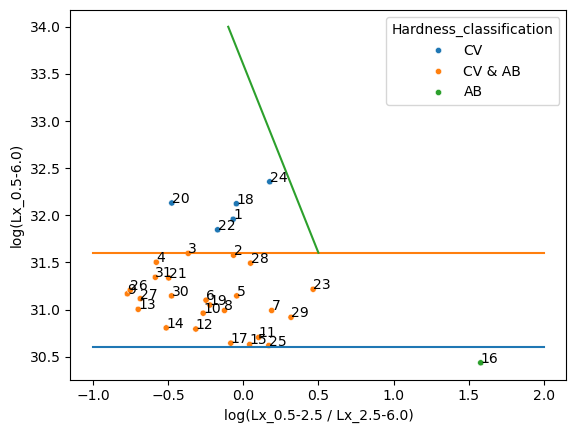

In [23]:
x = np.linspace(-1, 2, 2)
a = [-0.1, 0.5]
b = [34, 31.6020599913]
sns.scatterplot(data=df, x="log(Lx_0.5-2.5 / Lx_2.5-6.0)", y="log(Lx_0.5-6.0)", hue="Hardness_classification", s = 20)
for i in range(len(df["log(Lx_0.5-6.0)"])):
    plt.annotate(df.index[i].replace(substring_to_remove, ""), (df["log(Lx_0.5-2.5 / Lx_2.5-6.0)"].iloc[i], df["log(Lx_0.5-6.0)"].iloc[i]), fontsize = 8)
plt.plot(x, [30.6020599913, 30.6020599913])
plt.plot(x, [31.6020599913, 31.6020599913])
plt.plot(a,b)
plt.show()


In [ ]:
df.index[0]